# Student Performance Prediction

**DATA SPEAKS!! — Student Performance Analysis**

This notebook completes the machine-learning stage of the existing Student Performance project. It reuses the already cleaned and encoded dataset produced by `01_eda_preprocessing.ipynb` and focuses on predicting the final mathematics grade **G3**.

> **Target leakage rule:** `G1` and `G2` are previous-period grades and are deliberately excluded from the predictors. `G3` remains a numerical regression target on the original 0–20 scale.

## 1. Objective

The objective is to determine whether student and school-related characteristics can predict final mathematics performance without using the earlier-period grades G1 and G2.

We compare three regression algorithms:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

All models are evaluated only on a held-out test set using **MAE, RMSE, and R²**.

## 2. Dataset Loading

The notebook uses `student_mat_cleaned.csv`, which was generated by the existing preprocessing notebook. No new categorical encoding is performed here.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_mat_cleaned.csv"
FIG_DIR = BASE_DIR / "outputs" / "figures"
RESULTS_DIR = BASE_DIR / "outputs" / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Run this notebook from the project root.")

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))
df.head()

Dataset shape: (395, 42)
Columns: 42


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,1,1,18,1,1,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,False,False,False,False,False,False,False,True,False,False,False,True,False
1,1,1,17,1,1,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,False,False,False,False,False,True,False,False,False,False,False,False,False
2,1,1,15,1,0,1,1,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,False,False,False,False,False,True,False,False,False,True,False,True,False
3,1,1,15,1,1,1,4,2,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,True,False,False,False,False,False,True,False,True,False,False,True,False
4,1,1,16,1,1,1,3,3,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,False,True,False,False,False,True,False,False,True,False,False,False,False


## 3. Data Preparation

The cleaned dataset is already encoded. We therefore perform only modelling-specific validation here: checking missing values, duplicate rows, target type, and the presence of G1/G2/G3.

In [2]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("G3 dtype:", df["G3"].dtype)
print("G3 range:", (df["G3"].min(), df["G3"].max()))
print("G1/G2/G3 present:", [c for c in ["G1", "G2", "G3"] if c in df.columns])

Missing values: 0
Duplicate rows: 0
G3 dtype: int64
G3 range: (np.int64(0), np.int64(20))
G1/G2/G3 present: ['G1', 'G2', 'G3']


## 4. Feature and Target Selection

`G3` is the target. `G1` and `G2` are excluded to avoid target leakage and to make the task a more meaningful prediction of final performance from student/background/behavioural variables.

In [3]:
TARGET = "G3"
LEAKAGE_COLUMNS = ["G1", "G2"]

if TARGET not in df.columns:
    raise KeyError("Target G3 is missing from the cleaned dataset.")

feature_columns = [c for c in df.columns if c not in [TARGET] + LEAKAGE_COLUMNS]
X = df[feature_columns].copy()
y = df[TARGET].copy()

# Convert boolean one-hot columns to numeric integers for a consistent modelling matrix.
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

print("Number of predictors:", X.shape[1])
print("Excluded from predictors:", [c for c in ["G1", "G2", "G3"] if c in df.columns and c not in feature_columns])
print("G1 in X?", "G1" in X.columns)
print("G2 in X?", "G2" in X.columns)
print("G3 in X?", "G3" in X.columns)

Number of predictors: 39
Excluded from predictors: ['G1', 'G2', 'G3']
G1 in X? False
G2 in X? False
G3 in X? False


## 5. Train-Test Split

A reproducible 80/20 split is used. The test set is kept completely separate until final model evaluation.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 316
Test samples: 79


## 6. Model 1 — Linear Regression

Linear Regression is used as a simple, interpretable baseline. Because the predictors have different numerical scales, `StandardScaler` is placed inside a pipeline so that scaling parameters are learned from the training data only.

In [5]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

## 7. Model 2 — Random Forest Regressor

Random Forest is a non-linear ensemble method that can capture interactions and non-linear relationships without requiring feature scaling.

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## 8. Model 3 — Gradient Boosting Regressor

Gradient Boosting builds an ensemble sequentially, with later trees focusing on errors made by earlier trees. It is also used without scaling because tree-based models do not require standardized predictors.

In [7]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    random_state=42,
    loss="squared_error"
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

## 9. Model Evaluation

The following metrics are calculated from the **test set only**:

- **MAE:** average absolute prediction error in grade points.
- **RMSE:** penalizes larger errors more strongly than MAE.
- **R²:** proportion of variance in the test-set target explained by the model relative to a mean-only baseline.

In [8]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, y_pred_linear),
    evaluate_model("Random Forest Regressor", y_test, y_pred_rf),
    evaluate_model("Gradient Boosting Regressor", y_test, y_pred_gb),
]).sort_values("RMSE").reset_index(drop=True)

results_rounded = results.copy()
for c in ["MAE", "RMSE", "R²"]:
    results_rounded[c] = results_rounded[c].round(4)

results_rounded

,Model,MAE,RMSE,R²
0,Random Forest Regressor,3.0810,3.8602,0.2733
1,Gradient Boosting Regressor,3.2513,4.0570,0.1973
2,Linear Regression,3.3953,4.1957,0.1415


## 10. Model Comparison

Lower MAE and RMSE are better; higher R² is better. The best model under each metric is selected directly from the calculated test-set results.

{'Best by RMSE': 'Random Forest Regressor', 'Best by MAE': 'Random Forest Regressor', 'Best by R²': 'Random Forest Regressor'}


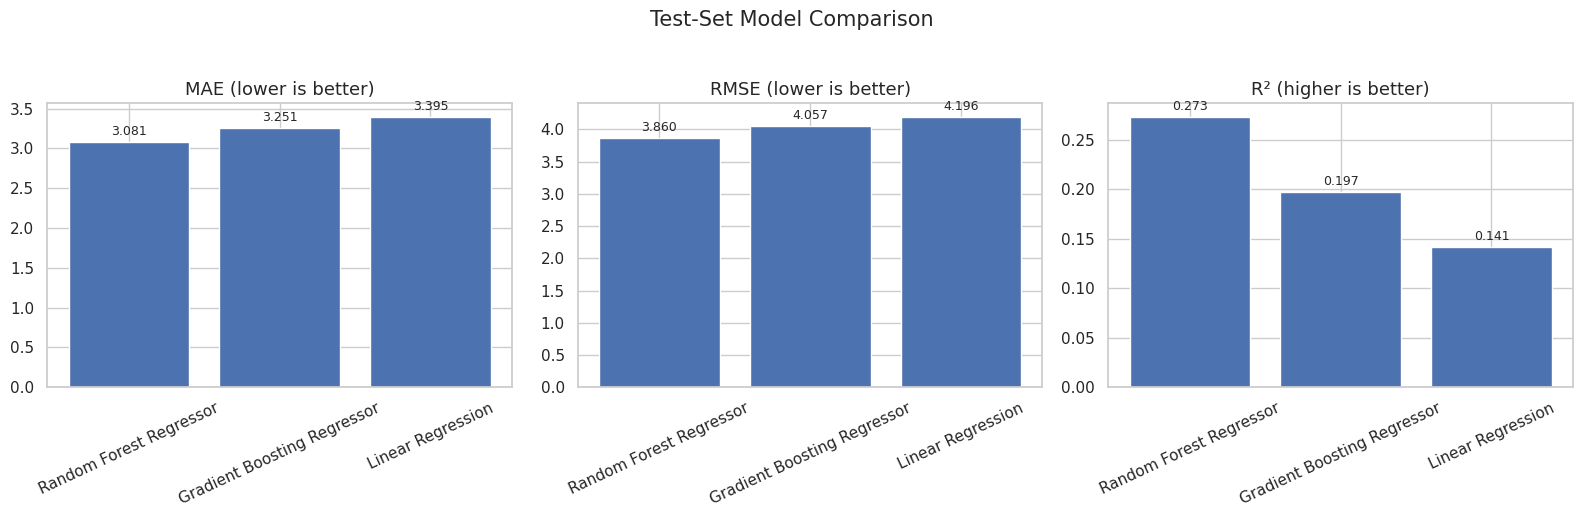

In [9]:
metric_best = {
    "Best by RMSE": results.loc[results["RMSE"].idxmin(), "Model"],
    "Best by MAE": results.loc[results["MAE"].idxmin(), "Model"],
    "Best by R²": results.loc[results["R²"].idxmax(), "Model"],
}
print(metric_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_specs = [("MAE", "MAE (lower is better)"), ("RMSE", "RMSE (lower is better)"), ("R²", "R² (higher is better)")]
for ax, (metric, title) in zip(axes, metric_specs):
    models = results["Model"].tolist()
    values = results[metric].to_numpy()
    bars = ax.bar(models, values)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
plt.suptitle("Test-Set Model Comparison", y=1.03, fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Best Model

For the primary selection criterion, RMSE is used because it gives additional weight to larger prediction errors. The notebook still reports the separate MAE and R² winners so that the choice is transparent.

In [10]:
predictions = {
    "Linear Regression": y_pred_linear,
    "Random Forest Regressor": y_pred_rf,
    "Gradient Boosting Regressor": y_pred_gb,
}

best_model_name = results.loc[results["RMSE"].idxmin(), "Model"]
best_predictions = predictions[best_model_name]
best_result = results.loc[results["Model"] == best_model_name].iloc[0]

print("Best overall model (lowest test RMSE):", best_model_name)
print(f"MAE:  {best_result['MAE']:.4f}")
print(f"RMSE: {best_result['RMSE']:.4f}")
print(f"R²:   {best_result['R²']:.4f}")

Best overall model (lowest test RMSE): Random Forest Regressor
MAE:  3.0810
RMSE: 3.8602
R²:   0.2733


## 12. Feature Importance

Feature importance is reported for the **best tree-based model**, selected between Random Forest and Gradient Boosting using test RMSE. This measures predictive importance within the fitted model; it does **not** establish causation.

In [11]:
tree_models = {
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gb_model,
}
tree_results = results[results["Model"].isin(tree_models.keys())].copy()
best_tree_name = tree_results.loc[tree_results["RMSE"].idxmin(), "Model"]
best_tree_model = tree_models[best_tree_name]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top_n = min(15, len(feature_importance))
top_features = feature_importance.head(top_n)
print("Best tree-based model:", best_tree_name)
top_features.round(5)

Best tree-based model: Random Forest Regressor


,Feature,Importance
0,absences,0.20689
1,failures,0.15735
2,health,0.05511
3,goout,0.04733
4,age,0.03778
5,studytime,0.03150
6,Fedu,0.03137
7,Medu,0.02953
8,Walc,0.02922
9,freetime,0.02894


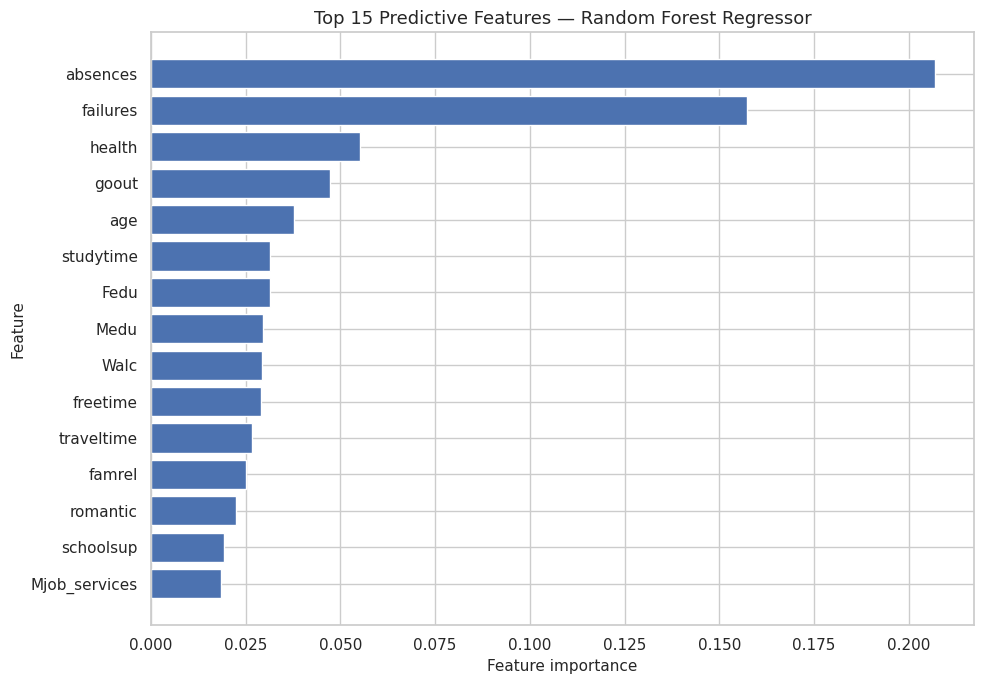

In [12]:
plt.figure(figsize=(10, 7))
plot_data = top_features.iloc[::-1]
plt.barh(plot_data["Feature"], plot_data["Importance"])
plt.title(f"Top {top_n} Predictive Features — {best_tree_name}")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


### Direction and Relationship of Important Features

Feature importance alone does not tell us whether a feature is positively or negatively associated with G3. To add context, Spearman correlations with G3 are calculated for the top features. For one-hot encoded variables, the sign should be interpreted as the association with the category represented by that indicator.

In [13]:
association_rows = []
for feature in top_features["Feature"]:
    rho = df[[feature, TARGET]].corr(method="spearman").iloc[0, 1]
    association_rows.append({"Feature": feature, "Spearman_rho_with_G3": rho})

associations = pd.DataFrame(association_rows).sort_values(
    "Spearman_rho_with_G3", ascending=False
).reset_index(drop=True)
associations.round(4)

,Feature,Spearman_rho_with_G3
0,Medu,0.2250
1,Fedu,0.1700
2,studytime,0.1052
3,Mjob_services,0.0863
4,famrel,0.0550
5,absences,0.0177
6,freetime,-0.0050
7,health,-0.0478
8,romantic,-0.0915
9,Walc,-0.1045


## 13. Actual vs Predicted Analysis

The plot below evaluates the best overall model on unseen test observations. Points close to the diagonal reference line indicate smaller prediction errors.

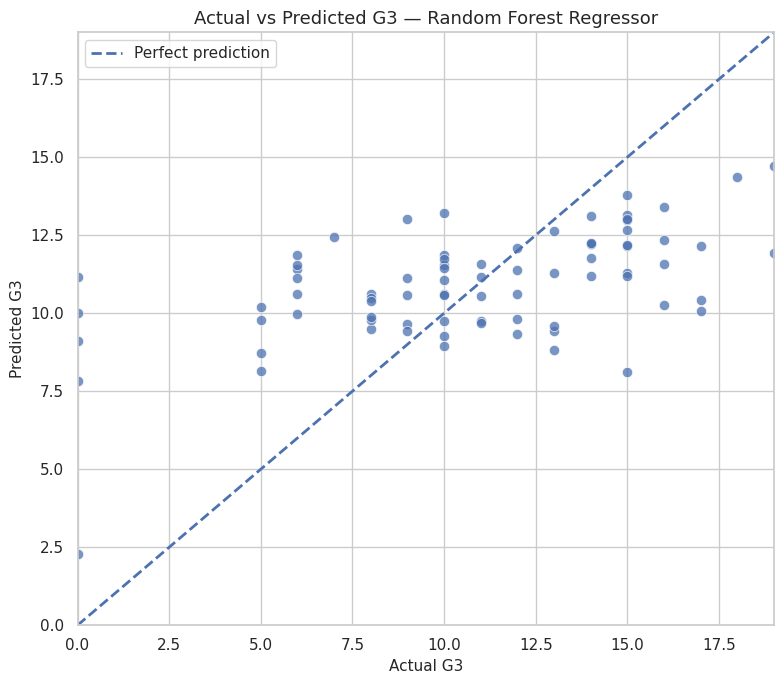

In [14]:
actual_pred = pd.DataFrame({"Actual": y_test.values, "Predicted": best_predictions})

plt.figure(figsize=(8, 7))
sns.scatterplot(data=actual_pred, x="Actual", y="Predicted", s=55, alpha=0.75)
lims = [min(actual_pred.min()), max(actual_pred.max())]
plt.plot(lims, lims, linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlim(lims)
plt.ylim(lims)
plt.title(f"Actual vs Predicted G3 — {best_model_name}")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

## 14. Residual Analysis

Residuals are calculated as `Actual − Predicted`. A useful residual plot should show errors scattered around zero without a strong systematic pattern.

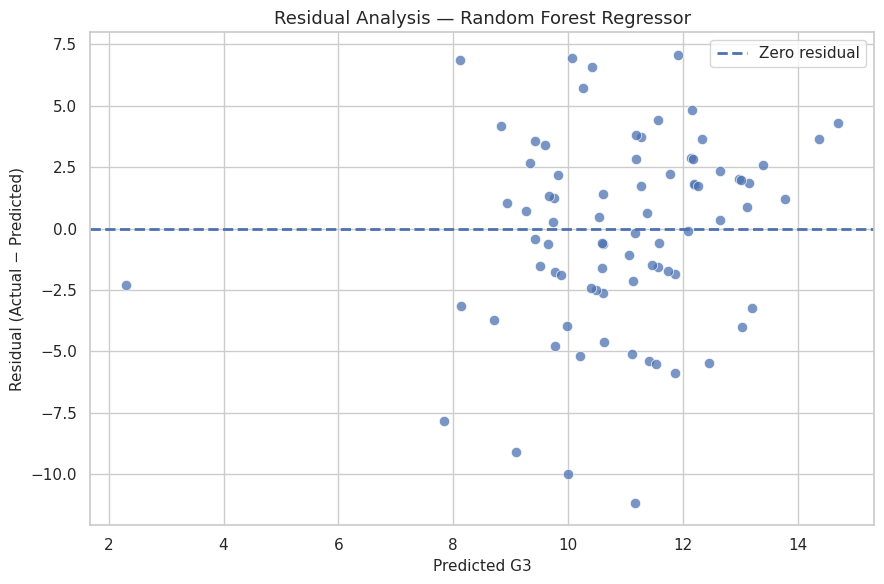

In [15]:
residuals = y_test.to_numpy() - best_predictions
residual_df = pd.DataFrame({
    "Predicted": best_predictions,
    "Residual": residuals
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=residual_df, x="Predicted", y="Residual", s=55, alpha=0.75)
plt.axhline(0, linestyle="--", linewidth=2, label="Zero residual")
plt.title(f"Residual Analysis — {best_model_name}")
plt.xlabel("Predicted G3")
plt.ylabel("Residual (Actual − Predicted)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_analysis.png", dpi=180, bbox_inches="tight")
plt.show()

## 15. Interpretation of Results

The following text is generated from the actual test-set metrics and feature-analysis outputs, so no model result is manually entered.

In [16]:
# Generate evidence-based interpretation from calculated results.
rmse_winner = metric_best["Best by RMSE"]
mae_winner = metric_best["Best by MAE"]
r2_winner = metric_best["Best by R²"]

mean_baseline = y_train.mean()
mae_best = best_result["MAE"]
r2_best = best_result["R²"]
rmse_best = best_result["RMSE"]

residual_mean = float(np.mean(residuals))
residual_std = float(np.std(residuals))

print("### Academic interpretation")
print(f"1. Model performance: {best_model_name} achieved the lowest test RMSE ({rmse_best:.4f}) and is therefore the primary model selected for this study.")
print(f"2. Metric winners: RMSE → {rmse_winner}; MAE → {mae_winner}; R² → {r2_winner}.")
print(f"3. Prediction error: the selected model's MAE is {mae_best:.4f} grade points, while its RMSE is {rmse_best:.4f} grade points.")
print(f"4. Explained variation: the selected model has a test R² of {r2_best:.4f}. This indicates how much of the test-set variation is explained relative to a mean-only baseline; it should not be interpreted as causal influence.")
print(f"5. Residuals: the mean residual is {residual_mean:.4f} with standard deviation {residual_std:.4f}. Visual inspection of the residual plot should be used to assess systematic patterns.")

print()
print("### Top predictive features")
for i, row in top_features.head(10).iterrows():
    rho = associations.loc[associations["Feature"] == row["Feature"], "Spearman_rho_with_G3"].iloc[0]
    direction = "positive" if rho > 0 else "negative" if rho < 0 else "near-zero"
    print(f"{i+1}. {row['Feature']} — importance={row['Importance']:.5f}; Spearman association={rho:.4f} ({direction})")

print()
print("### Important caution")
print("These are observational associations and model-based predictive patterns. Feature importance and correlation do not establish that a factor causes higher or lower grades.")


### Academic interpretation
1. Model performance: Random Forest Regressor achieved the lowest test RMSE (3.8602) and is therefore the primary model selected for this study.
2. Metric winners: RMSE → Random Forest Regressor; MAE → Random Forest Regressor; R² → Random Forest Regressor.
3. Prediction error: the selected model's MAE is 3.0810 grade points, while its RMSE is 3.8602 grade points.
4. Explained variation: the selected model has a test R² of 0.2733. This indicates how much of the test-set variation is explained relative to a mean-only baseline; it should not be interpreted as causal influence.
5. Residuals: the mean residual is -0.1508 with standard deviation 3.8573. Visual inspection of the residual plot should be used to assess systematic patterns.

### Top predictive features
1. absences — importance=0.20689; Spearman association=0.0177 (positive)
2. failures — importance=0.15735; Spearman association=-0.3612 (negative)
3. health — importance=0.05511; Spearman association=-0

## 16. Limitations

- The dataset contains 395 mathematics students, so estimates can vary with the train/test split.
- The analysis is based on a single dataset and may not generalize to other institutions or student populations.
- Some variables are behavioural or self-reported and may contain measurement/reporting bias.
- G1 and G2 were intentionally excluded because they are previous-period grades and would make the prediction task less informative through leakage.
- Test-set metrics are estimates rather than guarantees of future performance.
- Feature importance describes predictive contribution within the fitted model, not causal influence.
- The observational design does not allow causal claims such as “study time causes higher grades.”

## 17. Conclusion

The analysis compares three regression approaches for predicting final mathematics performance from non-grade predictors. The final conclusion below is generated from the calculated model results and top feature associations.

In [17]:
top5 = top_features.head(5)["Feature"].tolist()
print("DATA SPEAKS!! — ML RESULTS")
print("=" * 60)
print("Dataset: Student Performance — Mathematics")
print("Target: G3 (Final Grade)")
print("Models: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor")
print(f"Best Model: {best_model_name}")
print(f"Best RMSE: {rmse_best:.4f}")
print(f"Best MAE: {mae_best:.4f}")
print(f"Best R²: {r2_best:.4f}")
print("Top Predictive Features:")
for i, f in enumerate(top5, 1):
    print(f"{i}. {f}")

DATA SPEAKS!! — ML RESULTS
Dataset: Student Performance — Mathematics
Target: G3 (Final Grade)
Models: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor
Best Model: Random Forest Regressor
Best RMSE: 3.8602
Best MAE: 3.0810
Best R²: 0.2733
Top Predictive Features:
1. absences
2. failures
3. health
4. goout
5. age


### Website-ready Methodology

The modelling stage uses the cleaned and encoded Student Performance mathematics dataset. Final grade **G3** is treated as a numerical regression target, while **G1 and G2 are excluded** to prevent target leakage from previous-period grades. The data is divided into 80% training and 20% testing observations using a fixed random seed of 42. Three regression algorithms—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—are trained on the same predictor set. Linear Regression uses standardization inside an sklearn pipeline, while the tree-based models are trained without scaling. Performance is evaluated on the unseen test set using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². The best model is selected using test RMSE, with MAE and R² also reported for transparent comparison. Feature importance from the strongest tree-based model is used to identify predictive patterns, and residual/actual-versus-predicted plots are used to assess model behaviour.

### Website-ready Model Comparison

The comparison below is populated from the executed results table. Lower MAE and RMSE indicate smaller prediction errors, while higher R² indicates better explanatory performance relative to a mean-only baseline.

In [18]:
print(results_rounded.to_string(index=False))
print()
print(f"RMSE winner: {rmse_winner}")
print(f"MAE winner: {mae_winner}")
print(f"R² winner: {r2_winner}")


                      Model    MAE   RMSE     R²
    Random Forest Regressor 3.0810 3.8602 0.2733
Gradient Boosting Regressor 3.2513 4.0570 0.1973
          Linear Regression 3.3953 4.1957 0.1415

RMSE winner: Random Forest Regressor
MAE winner: Random Forest Regressor
R² winner: Random Forest Regressor


### Website-ready Key Findings

The following findings are generated from the actual results rather than being hard-coded.

In [19]:
print(f"• {best_model_name} is the primary model because it achieved the lowest test RMSE ({rmse_best:.4f}).")
print(f"• The selected model's average absolute prediction error is {mae_best:.4f} grade points (MAE).")
print(f"• The selected model's test R² is {r2_best:.4f}; this reflects predictive performance, not causation.")
print(f"• The strongest tree-model predictive features are: {', '.join(top5)}.")
print(f"• Spearman associations provide direction for the top features; these are associations with G3, not causal effects.")
print("• The residual analysis should be considered alongside the metrics to identify any systematic prediction errors.")

• Random Forest Regressor is the primary model because it achieved the lowest test RMSE (3.8602).
• The selected model's average absolute prediction error is 3.0810 grade points (MAE).
• The selected model's test R² is 0.2733; this reflects predictive performance, not causation.
• The strongest tree-model predictive features are: absences, failures, health, goout, age.
• Spearman associations provide direction for the top features; these are associations with G3, not causal effects.
• The residual analysis should be considered alongside the metrics to identify any systematic prediction errors.


### Website-ready Conclusion

This study demonstrates how machine-learning regression can be used to estimate students' final mathematics grades from demographic, academic-context, behavioural, and school-related variables while deliberately excluding previous-period grades. Among the tested algorithms, the model with the lowest test RMSE is selected as the primary predictor. The feature-importance analysis highlights the variables that contribute most to predictive performance in the fitted tree-based model. These findings can support exploratory educational analysis, but the results should be interpreted as predictive associations rather than causal relationships because the dataset is observational and relatively small. The model therefore provides useful evidence about patterns in this dataset, while further validation on larger and more diverse student populations would be needed before applying the conclusions broadly.

## 18. Save Results and Outputs

The final tables and predictions are saved so that the results can be reused by the report and the **Data Speaks!!** website.

In [20]:
# Save machine-readable outputs.
results.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
feature_importance.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)
associations.to_csv(RESULTS_DIR / "top_feature_associations.csv", index=False)
actual_pred.to_csv(RESULTS_DIR / "best_model_predictions.csv", index=False)

summary = pd.DataFrame({
    "Item": ["Dataset", "Target", "Best Model", "Best RMSE", "Best MAE", "Best R²", "Best Tree Model"],
    "Value": ["Student Performance — Mathematics", "G3", best_model_name, rmse_best, mae_best, r2_best, best_tree_name]
})
summary.to_csv(RESULTS_DIR / "ml_summary.csv", index=False)

print("Saved result files:")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", p.relative_to(BASE_DIR))
print()
print("Saved figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.relative_to(BASE_DIR))


Saved result files:
 - outputs/results/best_model_predictions.csv
 - outputs/results/feature_importance.csv
 - outputs/results/ml_summary.csv
 - outputs/results/model_comparison.csv
 - outputs/results/top_feature_associations.csv

Saved figures:
 - outputs/figures/actual_vs_predicted.png
 - outputs/figures/feature_importance.png
 - outputs/figures/model_comparison.png
 - outputs/figures/residual_analysis.png


## 19. Validation Checklist

The following assertions provide a final automated check before the notebook is considered complete.

In [21]:
assert "G1" not in X.columns, "Target leakage: G1 is present in X."
assert "G2" not in X.columns, "Target leakage: G2 is present in X."
assert TARGET not in X.columns, "Target leakage: G3 is present in X."
assert len(X_train) + len(X_test) == len(df)
assert set(results["Model"]) == {"Linear Regression", "Random Forest Regressor", "Gradient Boosting Regressor"}
assert results[["MAE", "RMSE", "R²"]].notna().all().all()
assert all((FIG_DIR / name).exists() for name in [
    "model_comparison.png", "actual_vs_predicted.png", "residual_analysis.png", "feature_importance.png"
])
assert all((RESULTS_DIR / name).exists() for name in [
    "model_comparison.csv", "feature_importance.csv", "top_feature_associations.csv", "best_model_predictions.csv", "ml_summary.csv"
])

print("ALL VALIDATION CHECKS PASSED")

ALL VALIDATION CHECKS PASSED
